# Homework 2 - SOM Neural Network
**Dataset:** IRIS 

This notebook implements a **Self-Organizing Map (SOM)** neural network from scratch and validates it using the MiniSom library.

The notebook is divided into two parts:
- **Part 1:** SOM implemented from scratch — training, topology experiments, learning rate experiments, and required plots.
- **Part 2:** Validation using MiniSom library (same approach as class tutorial).

## 1. Libraries

**Why:** We import all tools needed before starting.

**What each library does:**
- `pandas` — load and inspect the dataset as a table
- `numpy` — math operations and array manipulation (core of our SOM)
- `matplotlib` + `Axes3D` — 2D and 3D plots (Appendix 1 and 2)
- `sklearn.datasets` — provides the built-in IRIS dataset
- `sklearn.preprocessing.MinMaxScaler` — normalizes features to [0, 1]
- `minisom` — SOM library used in class, for validation only
- `np.random.seed(42)` — fixes randomness so results are the same every run


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

np.random.seed(42) # Fix random seed so results are reproducible

## 2. Load and Preprocess IRIS

**Why:** The SOM needs data to train on. IRIS is a classic dataset with 150 flower samples and 4 numeric features.

**What we do:**
1. Load the dataset and convert it to a DataFrame for easy inspection.
2. Normalize all features to [0, 1] using MinMaxScaler.

**Why normalize?** The SOM finds the Best Matching Unit using **euclidean distance**. If one feature has large values (e.g. 7.0) and another has small values (e.g. 0.2), the large one would unfairly dominate the distance calculation. Normalization puts all features on equal footing.

**What we get:** A clean, normalized matrix `X_scaled` of shape (150, 4) ready for training.

In [46]:
iris        = load_iris()
df          = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

X           = iris.data
y           = iris.target
class_names = iris.target_names

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [48]:
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape  : {X_scaled.shape}')      # Expected: (150, 4)
print(f'Min    : {X_scaled.min():.1f}')  # Expected: 0.0
print(f'Max    : {X_scaled.max():.1f}')  # Expected: 1.0
print(f'Classes: {class_names}')

Shape  : (150, 4)
Min    : 0.0
Max    : 1.0
Classes: ['setosa' 'versicolor' 'virginica']


# PART 1 — SOM from Scratch

## 3. Helper Functions

**Why:** Instead of writing everything in one giant block, we separate the SOM logic into small reusable functions. This makes the code easier to read and debug.

**What each function does:**

- `init_weights` — creates the initial neuron grid with random weights
- `find_bmu` — for each input vector, finds the neuron with the closest weights (the winner)
- `decay_learning_rate` — reduces alpha over time so the SOM fine-tunes at the end
- `decay_radius` — reduces the neighborhood radius over time so only close neurons update later
- `gaussian_influence` — calculates how much each neuron updates based on its distance to the BMU
- `quantization_error` — measures how well the SOM represents the data (lower = better)

**What we get:** Six functions ready to use in the training loop.

In [49]:
def init_weights(rows, cols, n_features):
    # Create a grid of neurons, each with a random weight vector of size n_features
    # Shape: (rows, cols, n_features)
    return np.random.rand(rows, cols, n_features)


def find_bmu(weights, x):
    # Compute euclidean distance from input x to every neuron in the grid
    # Return the (row, col) index of the neuron with the smallest distance
    diff      = weights - x                          # (rows, cols, n_features)
    distances = np.sqrt(np.sum(diff**2, axis=2))     # (rows, cols)
    return np.unravel_index(np.argmin(distances), distances.shape)


def decay_learning_rate(lr0, t, n_iter):
    # alpha(t) = alpha_0 * exp(-t / n_iter)
    # Starts high (fast learning) and decreases exponentially
    return lr0 * np.exp(-t / n_iter)


def decay_radius(sigma0, t, n_iter):
    # sigma(t) = sigma_0 * exp(-t / time_constant)
    # Neighborhood shrinks over time: early = broad update, late = local update
    time_constant = n_iter / np.log(sigma0 + 1e-10)
    return sigma0 * np.exp(-t / time_constant)


def gaussian_influence(grid_dist, sigma):
    # h(d) = exp( -d^2 / (2 * sigma^2) )
    # Neurons near the BMU get high influence (close to 1)
    # Neurons far from the BMU get low influence (close to 0)
    return np.exp(-(grid_dist**2) / (2 * sigma**2 + 1e-10))


def quantization_error(weights, data):
    # For each sample, find its BMU and compute the distance to it
    # Average all distances — this is the error we plot in Appendix 1
    total = 0.0
    for x in data:
        bmu = find_bmu(weights, x)
        total += np.sqrt(np.sum((x - weights[bmu])**2))
    return total / len(data)


print('Helper functions ready.')

Helper functions ready.


## 4. Training Function

**Why:** This is the main SOM algorithm. It repeats the same steps many times until the map organizes itself.

**What happens in each iteration:**
1. Decay `alpha` (learning rate) and `sigma` (radius) — both shrink over time
2. Pick a random sample from the data
3. Find the BMU — the neuron closest to that sample
4. Update the BMU and its neighbors: move their weights toward the sample
5. Record the quantization error

**What we get:** The trained weight matrix and a list of errors per iteration (used for Appendix 1).

In [50]:
def train_som(data, rows, cols, learning_rate=0.5, n_iterations=1000):
    n_features = data.shape[1]
    sigma0     = max(rows, cols) / 2   # initial neighborhood radius = half the grid

    weights = init_weights(rows, cols, n_features)
    errors  = []

    for t in range(n_iterations):

        alpha = decay_learning_rate(learning_rate, t, n_iterations)
        sigma = decay_radius(sigma0, t, n_iterations)

        # Pick a random training sample
        x = data[np.random.randint(0, len(data))]

        # Find its BMU
        bmu_r, bmu_c = find_bmu(weights, x)

        # Compute grid distance from every neuron to the BMU
        row_idx   = np.arange(rows).reshape(-1, 1)
        col_idx   = np.arange(cols).reshape(1, -1)
        grid_dist = np.sqrt((row_idx - bmu_r)**2 + (col_idx - bmu_c)**2)

        # Compute gaussian influence for each neuron
        h = gaussian_influence(grid_dist, sigma)   # shape: (rows, cols)

        # Update rule: w = w + alpha * h * (x - w)
        weights += alpha * h[:, :, np.newaxis] * (x - weights)

        # Record error at this step
        errors.append(quantization_error(weights, data))

    print(f'Done. Final error: {errors[-1]:.4f}')
    return weights, errors


print('train_som() ready.')

train_som() ready.


## 5. Test Different Topologies

**Why:** The grid size (topology) directly affects the quality of the SOM. A grid too small loses detail; too large and neurons go unused.

**What we do:** Train three different grid sizes — 5×5, 7×7, and 10×10 — all with the same learning rate (0.5) and iterations (1000), so the only variable is the grid size.

**Rule of thumb** (from the TA's notebook): `m = ceil( sqrt(5 * sqrt(n_samples)) )` → for IRIS (150 samples) this gives ≈ 8, so 7×7 and 10×10 are the closest candidates.

**What we get:** Three trained SOMs and their final errors. The one with the lowest error is our best topology.

In [51]:
topologies = [
    (5,  5,  'SOM 5x5'),
    (7,  7,  'SOM 7x7'),
    (10, 10, 'SOM 10x10'),
]

N_ITER = 1000
LR     = 0.5

topology_weights = {}
topology_errors  = {}

for rows, cols, name in topologies:
    print(f'Training {name}...')
    w, e = train_som(X_scaled, rows, cols, learning_rate=LR, n_iterations=N_ITER)
    topology_weights[name] = w
    topology_errors[name]  = e

print('\n── Final Quantization Errors ──')
for name, e in topology_errors.items():
    print(f'{name:12s} -> {e[-1]:.4f}')

Training SOM 5x5...
Done. Final error: 0.1407
Training SOM 7x7...
Done. Final error: 0.1042
Training SOM 10x10...
Done. Final error: 0.0871

── Final Quantization Errors ──
SOM 5x5      -> 0.1407
SOM 7x7      -> 0.1042
SOM 10x10    -> 0.0871


## 6. Test Different Learning Rates

**Why:** The learning rate controls how fast the weights move toward each input. It needs to be tuned — too high causes instability, too low means the map never fully organizes.

**What we do:** Fix the best topology and train 5 models with learning rates ranging from 0.1 to 0.9.

**What we get:** Five trained SOMs. The one with the lowest final error is our best learning rate.

> **Note:** Update `BEST_ROWS` and `BEST_COLS` below based on the results from cell 5.

In [52]:
# Update these based on the lowest error from cell 5
BEST_ROWS, BEST_COLS = 10, 10

learning_rates = [0.1, 0.3, 0.5, 0.7, 0.9]

lr_weights = {}
lr_errors  = {}

for lr in learning_rates:
    print(f'Training lr={lr}...')
    w, e = train_som(X_scaled, BEST_ROWS, BEST_COLS,
                     learning_rate=lr, n_iterations=N_ITER)
    lr_weights[lr] = w
    lr_errors[lr]  = e

print('\n── Final Errors by Learning Rate ──')
for lr, e in lr_errors.items():
    print(f'lr={lr:.1f} -> {e[-1]:.4f}')

Training lr=0.1...
Done. Final error: 0.0982
Training lr=0.3...
Done. Final error: 0.0915
Training lr=0.5...
Done. Final error: 0.0878
Training lr=0.7...
Done. Final error: 0.0845
Training lr=0.9...
Done. Final error: 0.0880

── Final Errors by Learning Rate ──
lr=0.1 -> 0.0982
lr=0.3 -> 0.0915
lr=0.5 -> 0.0878
lr=0.7 -> 0.0845
lr=0.9 -> 0.0880


## 7. Appendix 1 — Learning Curves

**Why:** We need to visually confirm that the SOM is actually learning — the error should decrease and stabilize over time, like the plot shown in the homework slide.

**What we plot:**
- Left chart: error curves for each topology (same lr=0.5)
- Right chart: error curves for each learning rate (same best topology)

**What we expect to see:** All curves start high and decrease toward a stable low value. Larger grids may converge slower. Very high or very low learning rates may converge poorly.

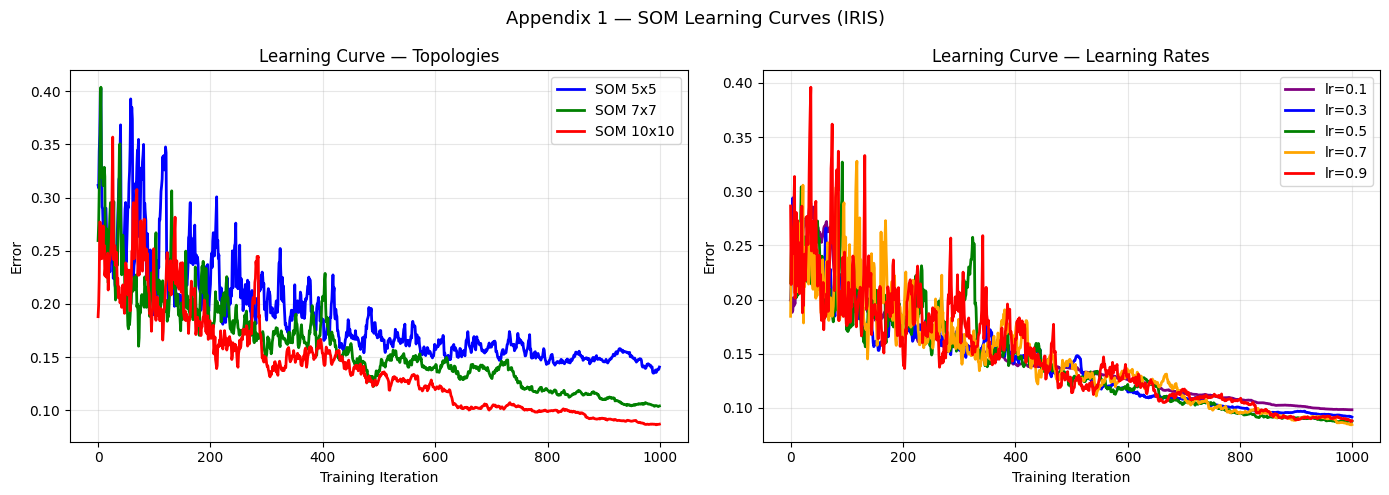

Saved: appendix1_learning_curves.png


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: topology comparison
colors = ['blue', 'green', 'red']
for (name, errors), color in zip(topology_errors.items(), colors):
    axes[0].plot(errors, color=color, linewidth=2, label=name)

axes[0].set_xlabel('Training Iteration')
axes[0].set_ylabel('Error')
axes[0].set_title('Learning Curve — Topologies')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: learning rate comparison
colors = ['purple', 'blue', 'green', 'orange', 'red']
for (lr, errors), color in zip(lr_errors.items(), colors):
    axes[1].plot(errors, color=color, linewidth=2, label=f'lr={lr}')

axes[1].set_xlabel('Training Iteration')
axes[1].set_ylabel('Error')
axes[1].set_title('Learning Curve — Learning Rates')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Appendix 1 — SOM Learning Curves (IRIS)', fontsize=13)
plt.tight_layout()
plt.savefig('appendix1_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: appendix1_learning_curves.png')

## 8. Appendix 2 — 3D Output Topology (Frequency Map)

**Why:** This is the required 3D plot from the homework. It shows how the 150 IRIS samples distributed themselves across the SOM grid after training.

**What the frequency map is:** For each neuron (i, j) in the grid, we count how many samples had that neuron as their BMU. This count becomes the Z axis.

**What we expect to see:** A surface with peaks (many samples mapped there = representative region) and valleys (few or no samples). Well-separated peaks suggest the SOM found distinct clusters.

> **Note:** Update `BEST_LR` below based on the lowest error from cell 6.

    x  y  frequency  percent
0   0  0          2   0.0133
1   0  1          1   0.0067
2   0  4          4   0.0267
3   0  5          1   0.0067
4   0  6          5   0.0333
5   0  7          3   0.0200
6   0  8          3   0.0200
7   1  0          1   0.0067
8   1  1          3   0.0200
9   1  4          2   0.0133
10  1  5          5   0.0333
11  1  6          4   0.0267
12  1  7          3   0.0200
13  1  9          5   0.0333
14  2  0          2   0.0133
15  2  1          1   0.0067
16  2  6          3   0.0200
17  2  8          5   0.0333
18  2  9          6   0.0400
19  3  0          1   0.0067
20  3  1          1   0.0067
21  3  2          1   0.0067
22  3  9          1   0.0067
23  4  0          1   0.0067
24  4  2          1   0.0067
25  4  4          3   0.0200
26  4  5          3   0.0200
27  4  6          2   0.0133
28  5  0          4   0.0267
29  5  2          2   0.0133
30  5  3          1   0.0067
31  5  4          3   0.0200
32  5  5          2   0.0133
33  5  6      

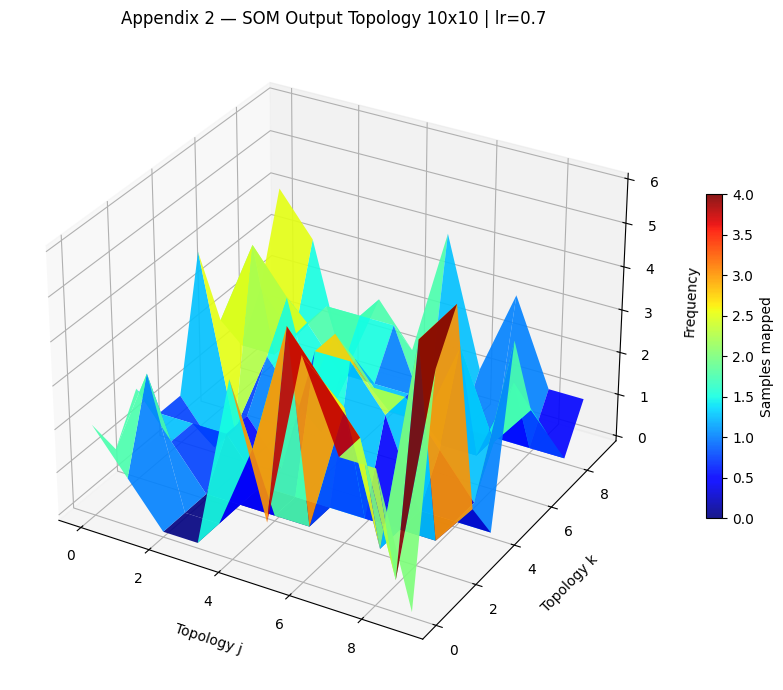

Saved: appendix2_3d_topology.png


In [54]:
# Update BEST_LR based on the lowest error from cell 6
BEST_LR      = 0.7
best_weights = lr_weights[BEST_LR]

# Count how many samples map to each neuron
freq_map = np.zeros((BEST_ROWS, BEST_COLS))
for x in X_scaled:
    bmu = find_bmu(best_weights, x)
    freq_map[bmu] += 1

# Print frequency table
freq_df = pd.DataFrame([
    {'x': i, 'y': j, 'frequency': int(freq_map[i, j]),
     'percent': round(freq_map[i, j] / len(X_scaled), 4)}
    for i in range(BEST_ROWS) for j in range(BEST_COLS)
    if freq_map[i, j] > 0
])
print(freq_df.to_string())

# 3D surface plot
J, K = np.meshgrid(np.arange(BEST_COLS), np.arange(BEST_ROWS))

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(J, K, freq_map, cmap='jet', edgecolor='none', alpha=0.9)

ax.set_xlabel('Topology j', labelpad=10)
ax.set_ylabel('Topology k', labelpad=10)
ax.set_zlabel('Frequency',  labelpad=10)
ax.set_title(f'Appendix 2 — SOM Output Topology {BEST_ROWS}x{BEST_COLS} | lr={BEST_LR}')

fig.colorbar(surf, ax=ax, shrink=0.5, label='Samples mapped')
plt.tight_layout()
plt.savefig('appendix2_3d_topology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: appendix2_3d_topology.png')

## 9. Summary — Best Configuration

**Why:** After all experiments, we consolidate the results in one place so we can clearly state which configuration performed best.

**What we get:** A printed comparison table and the automatically detected best topology and learning rate.

In [55]:
print('=' * 45)
print('TOPOLOGY COMPARISON  (lr=0.5, iter=1000)')
print('=' * 45)
for name, e in topology_errors.items():
    print(f'{name:12s} | Final Error: {e[-1]:.4f}')

print()
print('=' * 45)
print(f'LEARNING RATE COMPARISON  ({BEST_ROWS}x{BEST_COLS})')
print('=' * 45)
for lr, e in lr_errors.items():
    print(f'lr = {lr:.1f}       | Final Error: {e[-1]:.4f}')

print()
best_topo = min(topology_errors, key=lambda k: topology_errors[k][-1])
best_lr   = min(lr_errors,       key=lambda k: lr_errors[k][-1])
print(f'>>> Best topology     : {best_topo}')
print(f'>>> Best learning rate: {best_lr}')

TOPOLOGY COMPARISON  (lr=0.5, iter=1000)
SOM 5x5      | Final Error: 0.1407
SOM 7x7      | Final Error: 0.1042
SOM 10x10    | Final Error: 0.0871

LEARNING RATE COMPARISON  (10x10)
lr = 0.1       | Final Error: 0.0982
lr = 0.3       | Final Error: 0.0915
lr = 0.5       | Final Error: 0.0878
lr = 0.7       | Final Error: 0.0845
lr = 0.9       | Final Error: 0.0880

>>> Best topology     : SOM 10x10
>>> Best learning rate: 0.7


# PART 2 — Validation with MiniSom
*(Same approach as the class tutorial — used to verify our from-scratch implementation)*

**Why this section?** If our from-scratch SOM is correct, its quantization error should be in a similar range to MiniSom's. This is a standard way to validate a custom implementation.

## 10. Train MiniSom

**Why:** MiniSom is the SOM library recommended in class (and used in the TA's notebook). We use it here as a reference.

**What we do:** Calculate the optimal grid size using the same formula as the TA, then train with similar hyperparameters.

**What we get:** A trained MiniSom object ready to query.

In [56]:
# Grid size formula from TA: m = ceil( sqrt(5 * sqrt(n_samples)) )
# For IRIS (150 samples) -> ceil(sqrt(5 * sqrt(150))) = ceil(7.8) = 8
grid_size = int(np.ceil(np.sqrt(5 * np.sqrt(X_scaled.shape[0]))))
print(f'Recommended grid size: {grid_size}x{grid_size}')

som = MiniSom(
    x=grid_size, y=grid_size,
    input_len=X_scaled.shape[1],
    sigma=1.5,           # neighborhood radius
    learning_rate=0.5,   # same as our best lr
    random_seed=42
)
som.pca_weights_init(X_scaled)           # smarter initialization using PCA
som.train_batch(X_scaled, 10000, verbose=False)
print('MiniSom training complete.')

Recommended grid size: 8x8
MiniSom training complete.


## 11. Frequency Table (MiniSom)

**Why:** Same as our frequency map — we check how samples distributed across neurons.

**What we get:** A table with (x, y, frequency, percent) for each active neuron.

In [57]:
winner_coordinates = np.array([som.winner(x) for x in X_scaled])
map_df = pd.DataFrame(winner_coordinates, columns=['x', 'y'])

df_counts = map_df.groupby(['x', 'y']).size().reset_index(name='frequency')
df_counts['percent'] = (df_counts['frequency'] / len(X_scaled)).round(4)
print(df_counts.to_string())

    x  y  frequency  percent
0   0  0          2   0.0133
1   0  1          2   0.0133
2   0  2          3   0.0200
3   0  3          3   0.0200
4   0  4          4   0.0267
5   0  5          5   0.0333
6   0  6          1   0.0067
7   0  7          2   0.0133
8   1  0          3   0.0200
9   1  1          1   0.0067
10  1  2          4   0.0267
11  1  4          1   0.0067
12  1  5          5   0.0333
13  1  6          1   0.0067
14  1  7          4   0.0267
15  2  0          2   0.0133
16  2  1          1   0.0067
17  2  3          2   0.0133
18  2  4          3   0.0200
19  2  5          4   0.0267
20  2  6          1   0.0067
21  2  7          2   0.0133
22  3  0          2   0.0133
23  3  1          3   0.0200
24  3  2          3   0.0200
25  3  3          3   0.0200
26  3  4          3   0.0200
27  3  5          2   0.0133
28  3  6          2   0.0133
29  3  7          1   0.0067
30  4  0          4   0.0267
31  4  1          2   0.0133
32  4  2          3   0.0200
33  4  3      

## 12. MiniSom — U-Matrix 3D

**Why:** The U-Matrix shows the average distance between neighboring neurons. Peaks = cluster boundaries, valleys = cluster centers. This complements our frequency map.

**What we get:** A 3D surface similar to Appendix 2 but showing distances instead of frequencies.

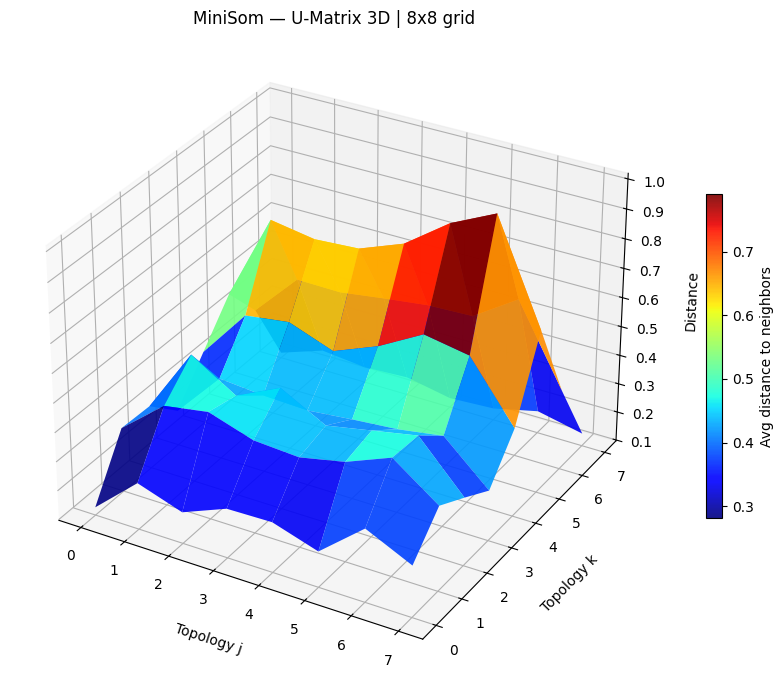

Saved: minisom_umatrix_3d.png


In [58]:
u_matrix = som.distance_map()

J_m, K_m = np.meshgrid(np.arange(u_matrix.shape[1]), np.arange(u_matrix.shape[0]))

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(J_m, K_m, u_matrix, cmap='jet', edgecolor='none', alpha=0.9)

ax.set_xlabel('Topology j', labelpad=10)
ax.set_ylabel('Topology k', labelpad=10)
ax.set_zlabel('Distance',   labelpad=10)
ax.set_title(f'MiniSom — U-Matrix 3D | {grid_size}x{grid_size} grid')

fig.colorbar(surf, ax=ax, shrink=0.5, label='Avg distance to neighbors')
plt.tight_layout()
plt.savefig('minisom_umatrix_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: minisom_umatrix_3d.png')

## 13. MiniSom — Species Map

**Why:** We overlay the 3 IRIS species on the U-Matrix to see if the SOM correctly separated them into distinct regions.

**What we expect:** Each species (setosa, versicolor, virginica) should cluster in a different zone of the map. If they overlap significantly, the SOM did not separate them well.

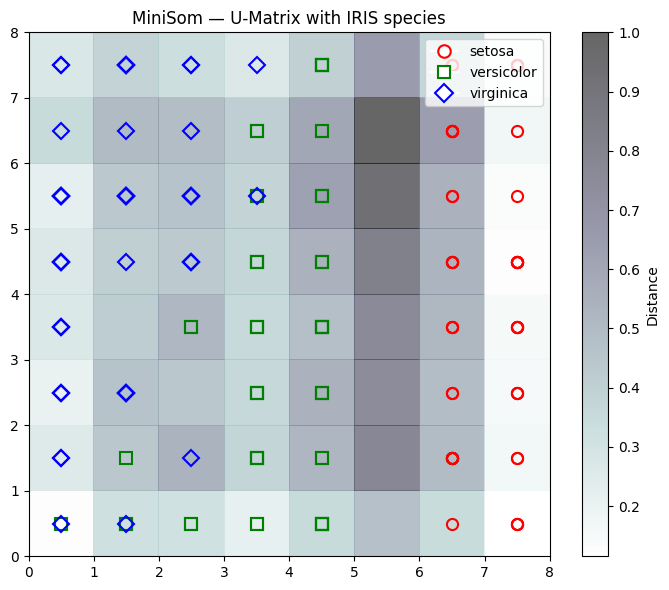

Saved: minisom_umatrix_classes.png


In [59]:
markers = ['o', 's', 'D']
colors  = ['r', 'g', 'b']

plt.figure(figsize=(7, 6))
plt.pcolor(u_matrix.T, cmap='bone_r', alpha=0.6)
plt.colorbar(label='Distance')

for cnt, x in enumerate(X_scaled):
    w = som.winner(x)
    c = y[cnt]
    plt.plot(w[0] + 0.5, w[1] + 0.5,
             markers[c], markerfacecolor='None',
             markeredgecolor=colors[c], markersize=8, markeredgewidth=1.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker=markers[i], color='w', label=class_names[i],
           markeredgecolor=colors[i], markersize=9, markeredgewidth=1.5)
    for i in range(3)
]
plt.legend(handles=legend_elements, loc='upper right')
plt.title('MiniSom — U-Matrix with IRIS species')
plt.tight_layout()
plt.savefig('minisom_umatrix_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: minisom_umatrix_classes.png')

## 14. Error Comparison — Scratch vs MiniSom

**Why:** This is the validation step. If both errors are in a similar range, it confirms our from-scratch implementation is correct.

**What we get:** A direct numeric comparison between our implementation and MiniSom.

**What to expect:** The errors won't be identical (different grid sizes and initialization methods), but they should be in the same ballpark.

In [60]:
minisom_qe = som.quantization_error(X_scaled)
scratch_qe = lr_errors[BEST_LR][-1]

print('=' * 50)
print('QUANTIZATION ERROR COMPARISON')
print('=' * 50)
print(f'SOM from scratch ({BEST_ROWS}x{BEST_COLS}, lr={BEST_LR}): {scratch_qe:.4f}')
print(f'MiniSom          ({grid_size}x{grid_size},  lr=0.5 ): {minisom_qe:.4f}')
print()
print('If both values are in a similar range, our from-scratch')
print('implementation is validated as correct.')

QUANTIZATION ERROR COMPARISON
SOM from scratch (10x10, lr=0.7): 0.0845
MiniSom          (8x8,  lr=0.5 ): 0.0628

If both values are in a similar range, our from-scratch
implementation is validated as correct.
